# Black Grouse 2030 Land-Use Scenario Project

## Stage 2: Harmonising HGN1990, LGN7 2012, and LGN2024

This notebook will:

1. Clip all three land-use rasters to the Sallandse Heuvelrug 5 km buffered study area.
2. Inspect the land-use classes occurring inside the study area.
3. Reclassify each dataset into a common habitat classification.
4. Align all datasets to a common 25 m grid in EPSG:28992.
5. Save harmonised rasters for 1990, 2012, and 2024.

In [1]:
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rasterio

from rasterio.mask import mask
from rasterio.warp import reproject, Resampling

print("All required packages imported successfully.")

All required packages imported successfully.


In [2]:
PROJECT_DIR = Path.cwd()

RAW_DIR = PROJECT_DIR / "data" / "raw"
PROCESSED_DIR = PROJECT_DIR / "data" / "processed"

OUTPUT_DIR = PROJECT_DIR / "outputs"
MAPS_DIR = OUTPUT_DIR / "maps"
TABLES_DIR = OUTPUT_DIR / "tables"
FIGURES_DIR = OUTPUT_DIR / "figures"

HGN1990_PATH = RAW_DIR / "HGN_1990.tif"
LGN2012_PATH = RAW_DIR / "LGN7_2012.tif"
LGN2024_PATH = RAW_DIR / "LGN_2024.tif"

BUFFER_PATH = (
    PROCESSED_DIR
    / "Sallandse_Heuvelrug_5km_buffer.gpkg"
)

INPUT_RASTERS = {
    "HGN1990": HGN1990_PATH,
    "LGN7_2012": LGN2012_PATH,
    "LGN2024": LGN2024_PATH,
}

print("Project directory:")
print(PROJECT_DIR)

print("\nInput files:")

for name, path in INPUT_RASTERS.items():
    status = "FOUND" if path.exists() else "MISSING"
    print(f"{name}: {status}")
    print(path)

buffer_status = "FOUND" if BUFFER_PATH.exists() else "MISSING"

print(f"\n5 km buffer: {buffer_status}")
print(BUFFER_PATH)

Project directory:
C:\Users\smit1\BlackGrouse_2030

Input files:
HGN1990: FOUND
C:\Users\smit1\BlackGrouse_2030\data\raw\HGN_1990.tif
LGN7_2012: FOUND
C:\Users\smit1\BlackGrouse_2030\data\raw\LGN7_2012.tif
LGN2024: FOUND
C:\Users\smit1\BlackGrouse_2030\data\raw\LGN_2024.tif

5 km buffer: FOUND
C:\Users\smit1\BlackGrouse_2030\data\processed\Sallandse_Heuvelrug_5km_buffer.gpkg


In [3]:
buffer_5km = gpd.read_file(BUFFER_PATH)

if buffer_5km.empty:
    raise ValueError("The 5 km buffer contains no features.")

if buffer_5km.crs is None:
    raise ValueError("The 5 km buffer has no CRS.")

buffer_5km = buffer_5km.to_crs("EPSG:28992")

print("Buffer loaded successfully.")
print(f"CRS: {buffer_5km.crs}")
print(f"Number of features: {len(buffer_5km)}")
print(f"Area: {buffer_5km.geometry.area.sum() / 1_000_000:.2f} km²")

Buffer loaded successfully.
CRS: EPSG:28992
Number of features: 1
Area: 762.89 km²


In [4]:
from rasterio.mask import mask


def clip_raster_to_buffer(
    input_path: Path,
    output_path: Path,
    buffer_gdf: gpd.GeoDataFrame,
) -> None:
    """
    Clip a categorical raster to the supplied buffer boundary
    and save the result as a compressed GeoTIFF.
    """

    with rasterio.open(input_path) as src:

        geometry = buffer_gdf.to_crs(src.crs).geometry

        clipped_array, clipped_transform = mask(
            src,
            geometry,
            crop=True,
            filled=True,
            nodata=0,
        )

        output_metadata = src.meta.copy()

        output_metadata.update(
            {
                "driver": "GTiff",
                "height": clipped_array.shape[1],
                "width": clipped_array.shape[2],
                "transform": clipped_transform,
                "nodata": 0,
                "compress": "lzw",
            }
        )

        with rasterio.open(
            output_path,
            "w",
            **output_metadata,
        ) as destination:
            destination.write(clipped_array)

    print(f"Saved: {output_path.name}")


CLIPPED_RASTERS = {
    "HGN1990": PROCESSED_DIR / "HGN1990_buffer_clipped.tif",
    "LGN7_2012": PROCESSED_DIR / "LGN7_2012_buffer_clipped.tif",
    "LGN2024": PROCESSED_DIR / "LGN2024_buffer_clipped.tif",
}


for dataset_name, input_path in INPUT_RASTERS.items():

    print(f"\nClipping {dataset_name}...")

    clip_raster_to_buffer(
        input_path=input_path,
        output_path=CLIPPED_RASTERS[dataset_name],
        buffer_gdf=buffer_5km,
    )

print("\nAll three rasters were clipped successfully.")


Clipping HGN1990...
Saved: HGN1990_buffer_clipped.tif

Clipping LGN7_2012...
Saved: LGN7_2012_buffer_clipped.tif

Clipping LGN2024...
Saved: LGN2024_buffer_clipped.tif

All three rasters were clipped successfully.


In [5]:
clipped_records = []

for dataset_name, raster_path in CLIPPED_RASTERS.items():

    with rasterio.open(raster_path) as src:
        clipped_records.append(
            {
                "dataset": dataset_name,
                "file": raster_path.name,
                "crs": str(src.crs),
                "width_pixels": src.width,
                "height_pixels": src.height,
                "resolution_x": abs(src.res[0]),
                "resolution_y": abs(src.res[1]),
                "data_type": src.dtypes[0],
                "nodata": src.nodata,
                "left": round(src.bounds.left, 2),
                "bottom": round(src.bounds.bottom, 2),
                "right": round(src.bounds.right, 2),
                "top": round(src.bounds.top, 2),
            }
        )

clipped_raster_information = pd.DataFrame(clipped_records)

display(clipped_raster_information)

,dataset,file,crs,width_pixels,height_pixels,resolution_x,resolution_y,data_type,nodata,left,bottom,right,top
0,HGN1990,HGN1990_buffer_clipped.tif,EPSG:28992,1023,1592,25.0,25.0,uint8,0.0,214050.0,468175.0,239625.0,507975.0
1,LGN7_2012,LGN7_2012_buffer_clipped.tif,EPSG:28992,1023,1592,25.0,25.0,uint8,0.0,214050.0,468175.0,239625.0,507975.0
2,LGN2024,LGN2024_buffer_clipped.tif,EPSG:28992,5109,7960,5.0,5.0,uint16,0.0,214070.0,468175.0,239615.0,507975.0


In [6]:
class_count_records = []

for dataset_name, raster_path in CLIPPED_RASTERS.items():

    with rasterio.open(raster_path) as src:
        raster_data = src.read(1)

    values, counts = np.unique(
        raster_data[raster_data != 0],
        return_counts=True,
    )

    for value, count in zip(values, counts):
        class_count_records.append(
            {
                "dataset": dataset_name,
                "class_value": int(value),
                "pixel_count": int(count),
            }
        )

class_counts = pd.DataFrame(class_count_records)

display(class_counts)

,dataset,class_value,pixel_count
0,HGN1990,1,622921
1,HGN1990,2,232294
2,HGN1990,3,33557
3,HGN1990,4,243747
4,HGN1990,6,61104
...,...,...,...
79,LGN2024,322,4064
80,LGN2024,323,97306
81,LGN2024,331,2533
82,LGN2024,332,5274


In [7]:
for dataset_name in class_counts["dataset"].unique():

    print(f"\n{'=' * 50}")
    print(dataset_name)
    print("=" * 50)

    dataset_table = class_counts[
        class_counts["dataset"] == dataset_name
    ][["class_value", "pixel_count"]]

    print(dataset_table.to_string(index=False))


HGN1990
 class_value  pixel_count
           1       622921
           2       232294
           3        33557
           4       243747
           6        61104
           7         8272
           8          194
           9          669
          12        17799
          13           43

LGN7_2012
 class_value  pixel_count
           1       554380
           2       180916
           3        11491
           4          697
           5         8772
           6         2091
           8           90
           9          192
          10         4589
          11       126558
          12        97989
          16        13522
          18        39596
          19         5579
          20         2043
          22         6172
          23        20005
          24           42
          25        19733
          26        41998
          28        12153
          35          502
          36        26786
          37         7472
          38         7302
          41      

In [8]:
LGN2024_ALIGNED_PATH = (
    PROCESSED_DIR / "LGN2024_25m_aligned.tif"
)

# HGN1990 provides the reference 25 m grid
with rasterio.open(CLIPPED_RASTERS["HGN1990"]) as reference:

    reference_crs = reference.crs
    reference_transform = reference.transform
    reference_width = reference.width
    reference_height = reference.height

    reference_metadata = reference.meta.copy()


# Create an empty array for the aligned LGN2024 raster
aligned_lgn2024 = np.zeros(
    (reference_height, reference_width),
    dtype=np.uint16,
)


# Resample and align LGN2024
with rasterio.open(CLIPPED_RASTERS["LGN2024"]) as source:

    reproject(
        source=rasterio.band(source, 1),
        destination=aligned_lgn2024,
        src_transform=source.transform,
        src_crs=source.crs,
        src_nodata=source.nodata,
        dst_transform=reference_transform,
        dst_crs=reference_crs,
        dst_nodata=0,
        resampling=Resampling.mode,
    )


# Update output metadata
reference_metadata.update(
    {
        "driver": "GTiff",
        "dtype": "uint16",
        "count": 1,
        "nodata": 0,
        "compress": "lzw",
    }
)


# Save the aligned raster
with rasterio.open(
    LGN2024_ALIGNED_PATH,
    "w",
    **reference_metadata,
) as destination:

    destination.write(aligned_lgn2024, 1)


print("LGN2024 aligned successfully.")
print(LGN2024_ALIGNED_PATH)

LGN2024 aligned successfully.
C:\Users\smit1\BlackGrouse_2030\data\processed\LGN2024_25m_aligned.tif


In [9]:
ALIGNED_RASTERS = {
    "HGN1990": CLIPPED_RASTERS["HGN1990"],
    "LGN7_2012": CLIPPED_RASTERS["LGN7_2012"],
    "LGN2024": LGN2024_ALIGNED_PATH,
}


with rasterio.open(ALIGNED_RASTERS["HGN1990"]) as reference:

    reference_crs = reference.crs
    reference_transform = reference.transform
    reference_width = reference.width
    reference_height = reference.height
    reference_resolution = reference.res


alignment_records = []

for dataset_name, raster_path in ALIGNED_RASTERS.items():

    with rasterio.open(raster_path) as src:

        same_grid = (
            src.crs == reference_crs
            and src.transform == reference_transform
            and src.width == reference_width
            and src.height == reference_height
            and src.res == reference_resolution
        )

        alignment_records.append(
            {
                "dataset": dataset_name,
                "width": src.width,
                "height": src.height,
                "resolution": src.res,
                "crs": str(src.crs),
                "same_reference_grid": same_grid,
            }
        )


alignment_table = pd.DataFrame(alignment_records)

display(alignment_table)

,dataset,width,height,resolution,crs,same_reference_grid
0,HGN1990,1023,1592,"(25.0, 25.0)",EPSG:28992,True
1,LGN7_2012,1023,1592,"(25.0, 25.0)",EPSG:28992,True
2,LGN2024,1023,1592,"(25.0, 25.0)",EPSG:28992,True


In [11]:
with rasterio.open(CLIPPED_RASTERS["LGN2024"]) as src:
    original_2024 = src.read(1)

with rasterio.open(LGN2024_ALIGNED_PATH) as src:
    aligned_2024 = src.read(1)

original_values = set(
    np.unique(original_2024[original_2024 != 0]).tolist()
)

aligned_values = set(
    np.unique(aligned_2024[aligned_2024 != 0]).tolist()
)

unexpected_values = sorted(aligned_values - original_values)
removed_values = sorted(original_values - aligned_values)

print(f"Original LGN2024 classes: {len(original_values)}")
print(f"Aligned LGN2024 classes: {len(aligned_values)}")
print(f"Unexpected classes created: {unexpected_values}")
print(f"Classes removed during modal aggregation: {removed_values}")

Original LGN2024 classes: 43
Aligned LGN2024 classes: 43
Unexpected classes created: []
Classes removed during modal aggregation: []


In [12]:
HARMONISED_CLASS_NAMES = {
    0: "Background",
    1: "Agricultural matrix",
    2: "Core habitat",
    3: "Forest",
    4: "Urban and infrastructure",
    5: "Water",
}


def create_reclassification_dictionary(class_groups):
    """
    Convert grouped source codes into a source-to-target
    reclassification dictionary.
    """

    reclassification = {}

    for target_class, source_codes in class_groups.items():

        for source_code in source_codes:

            if source_code in reclassification:
                raise ValueError(
                    f"Source code {source_code} occurs more than once."
                )

            reclassification[source_code] = target_class

    return reclassification


HGN1990_GROUPS = {
    1: [1, 2],
    2: [3, 8, 9],
    3: [4],
    4: [6, 12, 13],
    5: [7],
}


LGN7_2012_GROUPS = {
    1: [1, 2, 3, 4, 5, 6, 8, 9, 10, 61, 62],
    2: [35, 36, 37, 38, 41, 42, 45],
    3: [11, 12, 20, 22, 43],
    4: [18, 19, 23, 24, 25, 26, 28],
    5: [16],
}


LGN2024_GROUPS = {
    1: [1, 2, 3, 4, 5, 6, 8, 9, 10, 61, 62],

    2: [
        35, 36, 37, 38, 39,
        41, 42, 45, 47,
        321, 322, 323,
        331, 332, 333,
    ],

    3: [11, 12, 20, 22, 40, 43],

    4: [
        18, 19, 23, 26, 27, 28, 29,
        251, 252, 253,
    ],

    5: [16],
}


RECLASSIFICATION_RULES = {
    "HGN1990": create_reclassification_dictionary(
        HGN1990_GROUPS
    ),

    "LGN7_2012": create_reclassification_dictionary(
        LGN7_2012_GROUPS
    ),

    "LGN2024": create_reclassification_dictionary(
        LGN2024_GROUPS
    ),
}


validation_records = []

for dataset_name, raster_path in ALIGNED_RASTERS.items():

    with rasterio.open(raster_path) as src:
        raster_data = src.read(1)

    observed_codes = sorted(
        np.unique(
            raster_data[raster_data != 0]
        ).astype(int).tolist()
    )

    mapped_codes = sorted(
        RECLASSIFICATION_RULES[dataset_name].keys()
    )

    unmapped_codes = sorted(
        set(observed_codes) - set(mapped_codes)
    )

    unused_mapping_codes = sorted(
        set(mapped_codes) - set(observed_codes)
    )

    validation_records.append(
        {
            "dataset": dataset_name,
            "observed_class_count": len(observed_codes),
            "mapped_class_count": len(mapped_codes),
            "unmapped_codes": unmapped_codes,
            "unused_mapping_codes": unused_mapping_codes,
        }
    )


reclassification_validation = pd.DataFrame(
    validation_records
)

display(reclassification_validation)

,dataset,observed_class_count,mapped_class_count,unmapped_codes,unused_mapping_codes
0,HGN1990,10,10,[],[]
1,LGN7_2012,31,31,[],[]
2,LGN2024,43,43,[],[]


In [13]:
HARMONISED_RASTERS = {
    "HGN1990": PROCESSED_DIR / "HGN1990_harmonised_25m.tif",
    "LGN7_2012": PROCESSED_DIR / "LGN7_2012_harmonised_25m.tif",
    "LGN2024": PROCESSED_DIR / "LGN2024_harmonised_25m.tif",
}


def reclassify_raster(
    input_path: Path,
    output_path: Path,
    reclassification_rules: dict,
) -> None:
    """
    Reclassify a categorical raster and save it as uint8.
    Value 0 remains background or NoData.
    """

    with rasterio.open(input_path) as src:
        source_data = src.read(1)
        output_metadata = src.meta.copy()

    harmonised_data = np.zeros(
        source_data.shape,
        dtype=np.uint8,
    )

    for source_class, target_class in reclassification_rules.items():
        harmonised_data[source_data == source_class] = target_class

    output_metadata.update(
        {
            "driver": "GTiff",
            "dtype": "uint8",
            "count": 1,
            "nodata": 0,
            "compress": "lzw",
        }
    )

    with rasterio.open(
        output_path,
        "w",
        **output_metadata,
    ) as destination:
        destination.write(harmonised_data, 1)

    print(f"Saved: {output_path.name}")


for dataset_name, input_path in ALIGNED_RASTERS.items():

    print(f"\nReclassifying {dataset_name}...")

    reclassify_raster(
        input_path=input_path,
        output_path=HARMONISED_RASTERS[dataset_name],
        reclassification_rules=RECLASSIFICATION_RULES[
            dataset_name
        ],
    )

print("\nAll harmonised rasters were created successfully.")


Reclassifying HGN1990...
Saved: HGN1990_harmonised_25m.tif

Reclassifying LGN7_2012...
Saved: LGN7_2012_harmonised_25m.tif

Reclassifying LGN2024...
Saved: LGN2024_harmonised_25m.tif

All harmonised rasters were created successfully.


In [14]:
harmonised_records = []

pixel_area_km2 = (25 * 25) / 1_000_000

for dataset_name, raster_path in HARMONISED_RASTERS.items():

    with rasterio.open(raster_path) as src:
        raster_data = src.read(1)

    values, counts = np.unique(
        raster_data[raster_data != 0],
        return_counts=True,
    )

    for class_value, pixel_count in zip(values, counts):

        harmonised_records.append(
            {
                "dataset": dataset_name,
                "class_value": int(class_value),
                "class_name": HARMONISED_CLASS_NAMES[
                    int(class_value)
                ],
                "pixel_count": int(pixel_count),
                "area_km2": round(
                    int(pixel_count) * pixel_area_km2,
                    2,
                ),
            }
        )


harmonised_class_summary = pd.DataFrame(
    harmonised_records
)

display(harmonised_class_summary)

,dataset,class_value,class_name,pixel_count,area_km2
0,HGN1990,1,Agricultural matrix,855215,534.51
1,HGN1990,2,Core habitat,34420,21.51
2,HGN1990,3,Forest,243747,152.34
3,HGN1990,4,Urban and infrastructure,78946,49.34
4,HGN1990,5,Water,8272,5.17
5,LGN7_2012,1,Agricultural matrix,766060,478.79
6,LGN7_2012,2,Core habitat,68403,42.75
7,LGN7_2012,3,Forest,233509,145.94
8,LGN7_2012,4,Urban and infrastructure,139106,86.94
9,LGN7_2012,5,Water,13522,8.45


In [15]:
import os

from rasterio.features import geometry_mask


# Use the HGN1990 grid as the common reference grid
with rasterio.open(ALIGNED_RASTERS["HGN1990"]) as reference:

    reference_crs = reference.crs
    reference_transform = reference.transform
    reference_height = reference.height
    reference_width = reference.width


# Ensure the buffer uses the reference CRS
buffer_for_mask = buffer_5km.to_crs(reference_crs)

buffer_geometries = [
    geometry.__geo_interface__
    for geometry in buffer_for_mask.geometry
    if geometry is not None and not geometry.is_empty
]


# True represents pixels inside the buffered study area
common_analysis_mask = geometry_mask(
    buffer_geometries,
    out_shape=(reference_height, reference_width),
    transform=reference_transform,
    invert=True,
    all_touched=False,
)


print(
    "Pixels inside common analysis mask:",
    int(common_analysis_mask.sum()),
)

print(
    "Common analysis area:",
    f"{common_analysis_mask.sum() * 625 / 1_000_000:.2f} km²",
)


# Apply the identical mask to every harmonised raster
for dataset_name, raster_path in HARMONISED_RASTERS.items():

    with rasterio.open(raster_path) as src:
        raster_data = src.read(1)
        output_metadata = src.meta.copy()

    raster_data[~common_analysis_mask] = 0

    temporary_path = raster_path.with_name(
        f"{raster_path.stem}_temporary.tif"
    )

    with rasterio.open(
        temporary_path,
        "w",
        **output_metadata,
    ) as destination:
        destination.write(raster_data, 1)

    os.replace(temporary_path, raster_path)

    print(f"Common mask applied: {raster_path.name}")


# Verify the final analysed area
verification_records = []

for dataset_name, raster_path in HARMONISED_RASTERS.items():

    with rasterio.open(raster_path) as src:
        raster_data = src.read(1)

    analysed_pixels = int(np.count_nonzero(raster_data))

    verification_records.append(
        {
            "dataset": dataset_name,
            "analysed_pixels": analysed_pixels,
            "analysed_area_km2": round(
                analysed_pixels * 625 / 1_000_000,
                2,
            ),
        }
    )


common_mask_verification = pd.DataFrame(
    verification_records
)

display(common_mask_verification)

Pixels inside common analysis mask: 1220600
Common analysis area: 762.88 km²
Common mask applied: HGN1990_harmonised_25m.tif
Common mask applied: LGN7_2012_harmonised_25m.tif
Common mask applied: LGN2024_harmonised_25m.tif


,dataset,analysed_pixels,analysed_area_km2
0,HGN1990,1220600,762.88
1,LGN7_2012,1220600,762.88
2,LGN2024,1220600,762.88


In [16]:
final_summary_records = []

pixel_area_km2 = 625 / 1_000_000

for dataset_name, raster_path in HARMONISED_RASTERS.items():

    with rasterio.open(raster_path) as src:
        raster_data = src.read(1)

    analysed_data = raster_data[raster_data != 0]
    total_pixels = len(analysed_data)

    values, counts = np.unique(
        analysed_data,
        return_counts=True,
    )

    for class_value, pixel_count in zip(values, counts):

        final_summary_records.append(
            {
                "dataset": dataset_name,
                "class_value": int(class_value),
                "class_name": HARMONISED_CLASS_NAMES[
                    int(class_value)
                ],
                "pixel_count": int(pixel_count),
                "area_km2": round(
                    pixel_count * pixel_area_km2,
                    2,
                ),
                "percentage": round(
                    pixel_count / total_pixels * 100,
                    2,
                ),
            }
        )


final_harmonised_summary = pd.DataFrame(
    final_summary_records
)

SUMMARY_OUTPUT_PATH = (
    TABLES_DIR / "harmonised_landuse_class_summary.csv"
)

final_harmonised_summary.to_csv(
    SUMMARY_OUTPUT_PATH,
    index=False,
)

display(final_harmonised_summary)

print("\nSummary table saved:")
print(SUMMARY_OUTPUT_PATH)

,dataset,class_value,class_name,pixel_count,area_km2,percentage
0,HGN1990,1,Agricultural matrix,855215,534.51,70.07
1,HGN1990,2,Core habitat,34420,21.51,2.82
2,HGN1990,3,Forest,243747,152.34,19.97
3,HGN1990,4,Urban and infrastructure,78946,49.34,6.47
4,HGN1990,5,Water,8272,5.17,0.68
5,LGN7_2012,1,Agricultural matrix,766060,478.79,62.76
6,LGN7_2012,2,Core habitat,68403,42.75,5.60
7,LGN7_2012,3,Forest,233509,145.94,19.13
8,LGN7_2012,4,Urban and infrastructure,139106,86.94,11.40
9,LGN7_2012,5,Water,13522,8.45,1.11



Summary table saved:
C:\Users\smit1\BlackGrouse_2030\outputs\tables\harmonised_landuse_class_summary.csv


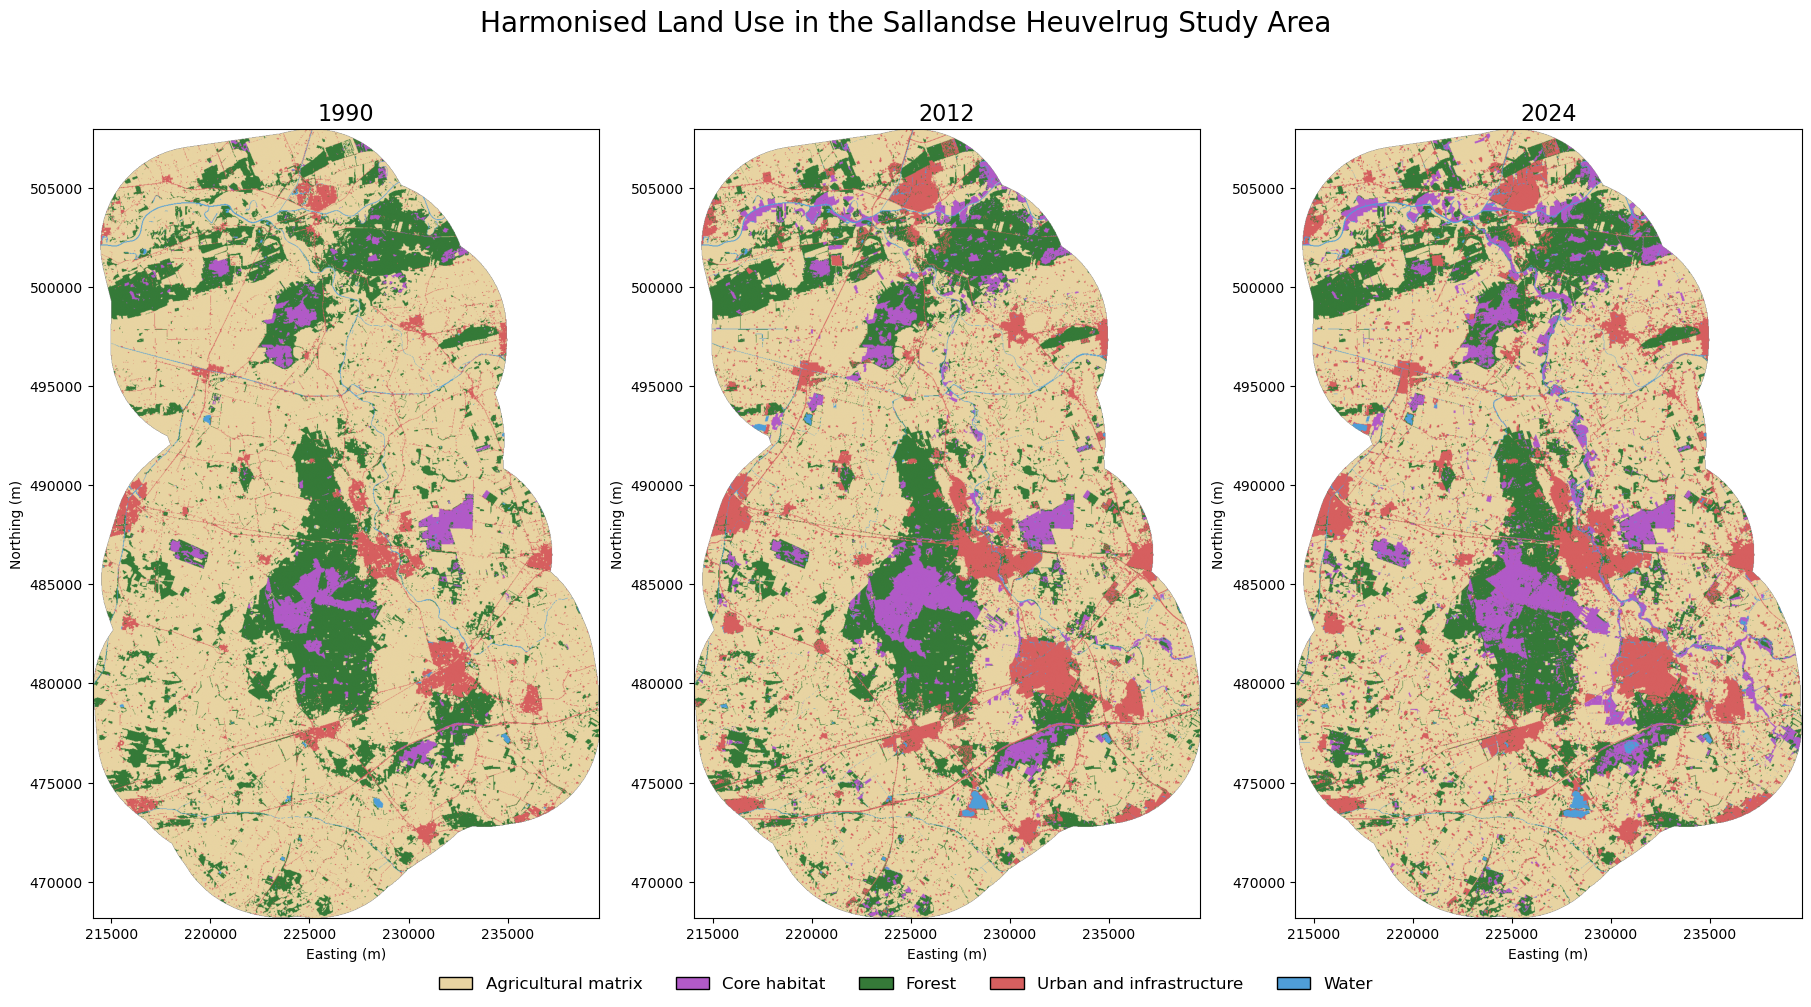

Figure saved:
C:\Users\smit1\BlackGrouse_2030\outputs\figures\harmonised_landuse_1990_2012_2024.png


In [17]:
from matplotlib.colors import BoundaryNorm, ListedColormap
from matplotlib.patches import Patch


CLASS_COLOURS = {
    1: "#e8d4a2",  # Agricultural matrix
    2: "#b15ac7",  # Core habitat
    3: "#357a38",  # Forest
    4: "#d65f5f",  # Urban and infrastructure
    5: "#4f9ed8",  # Water
}

CLASS_LABELS = {
    1: "Agricultural matrix",
    2: "Core habitat",
    3: "Forest",
    4: "Urban and infrastructure",
    5: "Water",
}

YEAR_LABELS = {
    "HGN1990": "1990",
    "LGN7_2012": "2012",
    "LGN2024": "2024",
}


landuse_colormap = ListedColormap(
    [CLASS_COLOURS[class_value] for class_value in range(1, 6)]
)

landuse_norm = BoundaryNorm(
    boundaries=[0.5, 1.5, 2.5, 3.5, 4.5, 5.5],
    ncolors=landuse_colormap.N,
)


fig, axes = plt.subplots(
    nrows=1,
    ncols=3,
    figsize=(18, 10),
    constrained_layout=True,
)


for axis, (dataset_name, raster_path) in zip(
    axes,
    HARMONISED_RASTERS.items(),
):

    with rasterio.open(raster_path) as src:

        raster_data = src.read(1)

        raster_extent = [
            src.bounds.left,
            src.bounds.right,
            src.bounds.bottom,
            src.bounds.top,
        ]

    masked_raster = np.ma.masked_where(
        raster_data == 0,
        raster_data,
    )

    axis.imshow(
        masked_raster,
        cmap=landuse_colormap,
        norm=landuse_norm,
        extent=raster_extent,
        origin="upper",
    )

    axis.set_title(
        YEAR_LABELS[dataset_name],
        fontsize=16,
    )

    axis.set_xlabel("Easting (m)")
    axis.set_ylabel("Northing (m)")
    axis.set_aspect("equal")


legend_items = [
    Patch(
        facecolor=CLASS_COLOURS[class_value],
        edgecolor="black",
        label=CLASS_LABELS[class_value],
    )
    for class_value in range(1, 6)
]


fig.legend(
    handles=legend_items,
    loc="lower center",
    ncol=5,
    frameon=False,
    fontsize=12,
)

fig.suptitle(
    "Harmonised Land Use in the Sallandse Heuvelrug Study Area",
    fontsize=20,
)


HARMONISED_MAP_OUTPUT = (
    FIGURES_DIR / "harmonised_landuse_1990_2012_2024.png"
)

plt.savefig(
    HARMONISED_MAP_OUTPUT,
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
)

plt.show()

print("Figure saved:")
print(HARMONISED_MAP_OUTPUT)

In [18]:
validation_records = []

reference_mask = None

for dataset_name, raster_path in HARMONISED_RASTERS.items():

    with rasterio.open(raster_path) as src:
        raster_data = src.read(1)

        current_mask = raster_data != 0
        observed_classes = sorted(
            np.unique(raster_data[current_mask]).astype(int).tolist()
        )

        if reference_mask is None:
            reference_mask = current_mask.copy()
            same_analysis_mask = True
        else:
            same_analysis_mask = np.array_equal(
                current_mask,
                reference_mask,
            )

        validation_records.append(
            {
                "dataset": dataset_name,
                "file_exists": raster_path.exists(),
                "crs": str(src.crs),
                "width": src.width,
                "height": src.height,
                "resolution_x": abs(src.res[0]),
                "resolution_y": abs(src.res[1]),
                "observed_classes": observed_classes,
                "analysed_pixels": int(current_mask.sum()),
                "same_analysis_mask": same_analysis_mask,
            }
        )


final_validation = pd.DataFrame(validation_records)

VALIDATION_OUTPUT_PATH = (
    TABLES_DIR / "harmonised_raster_validation.csv"
)

final_validation.to_csv(
    VALIDATION_OUTPUT_PATH,
    index=False,
)

display(final_validation)

all_checks_passed = (
    final_validation["file_exists"].all()
    and final_validation["same_analysis_mask"].all()
    and (final_validation["crs"] == "EPSG:28992").all()
    and (final_validation["width"] == 1023).all()
    and (final_validation["height"] == 1592).all()
    and (final_validation["resolution_x"] == 25.0).all()
    and (final_validation["resolution_y"] == 25.0).all()
    and final_validation["observed_classes"].apply(
        lambda values: values == [1, 2, 3, 4, 5]
    ).all()
)

if not all_checks_passed:
    raise ValueError(
        "One or more final harmonisation checks failed."
    )

print("\nAll final harmonisation checks passed.")
print("\nValidation table saved:")
print(VALIDATION_OUTPUT_PATH)

,dataset,file_exists,crs,width,height,resolution_x,resolution_y,observed_classes,analysed_pixels,same_analysis_mask
0,HGN1990,True,EPSG:28992,1023,1592,25.0,25.0,"[1, 2, 3, 4, 5]",1220600,True
1,LGN7_2012,True,EPSG:28992,1023,1592,25.0,25.0,"[1, 2, 3, 4, 5]",1220600,True
2,LGN2024,True,EPSG:28992,1023,1592,25.0,25.0,"[1, 2, 3, 4, 5]",1220600,True



All final harmonisation checks passed.

Validation table saved:
C:\Users\smit1\BlackGrouse_2030\outputs\tables\harmonised_raster_validation.csv
